# 📉 Phase 2 – Data Drift & Concept Drift Detection
**Goal:** Catch when real-world data changes and your model becomes stale.

Topics:
- Data drift (distribution shift in features)
- Concept drift (P(y|X) changes)
- Evidently AI reports
- Statistical tests: KS test, PSI, Chi-Squared

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from evidently.report import Report
from evidently.metric_preset import DataDriftPreset, TargetDriftPreset
from evidently.metrics import DatasetDriftMetric, DataDriftTable
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
print('Libraries ready!')

Libraries ready!


In [2]:
# Simulate training data (reference)
np.random.seed(42)
n_ref = 2000
reference_data = pd.DataFrame({
    'feature_1': np.random.normal(50, 10, n_ref),
    'feature_2': np.random.exponential(20, n_ref),
    'feature_3': np.random.uniform(0, 1, n_ref),
    'feature_4': np.random.choice(['A', 'B', 'C'], n_ref, p=[0.5, 0.3, 0.2]),
    'target': np.random.choice([0, 1], n_ref, p=[0.6, 0.4])
})

# Simulate production data 6 months later (with drift!)
n_prod = 1000
production_data = pd.DataFrame({
    'feature_1': np.random.normal(65, 15, n_prod),   # DRIFT: mean shifted +15
    'feature_2': np.random.exponential(35, n_prod),  # DRIFT: scale changed
    'feature_3': np.random.uniform(0.3, 1, n_prod),  # DRIFT: narrower range
    'feature_4': np.random.choice(['A', 'B', 'C'], n_prod, p=[0.2, 0.5, 0.3]),  # DRIFT: probs changed
    'target': np.random.choice([0, 1], n_prod, p=[0.35, 0.65])  # CONCEPT DRIFT
})

print(f'Reference: {reference_data.shape}, Production: {production_data.shape}')
print(f'Ref target rate: {reference_data.target.mean():.2f} | Prod target rate: {production_data.target.mean():.2f}')

Reference: (2000, 5), Production: (1000, 5)
Ref target rate: 0.38 | Prod target rate: 0.65


In [3]:
# Manual drift detection with KS test and PSI
def population_stability_index(ref, prod, bins=10):
    """PSI < 0.1 = no drift, 0.1-0.2 = slight drift, >0.2 = significant drift"""
    ref_counts, bin_edges = np.histogram(ref, bins=bins)
    prod_counts, _ = np.histogram(prod, bins=bin_edges)
    ref_pct = ref_counts / len(ref) + 1e-10
    prod_pct = prod_counts / len(prod) + 1e-10
    psi = np.sum((prod_pct - ref_pct) * np.log(prod_pct / ref_pct))
    return psi

print('Feature Drift Analysis:')
print(f'{"Feature":<15} {"KS stat":<10} {"KS p-value":<15} {"PSI":<10} {"Drift?"}')
print('-' * 60)
for col in ['feature_1', 'feature_2', 'feature_3']:
    ks_stat, p_val = stats.ks_2samp(reference_data[col], production_data[col])
    psi = population_stability_index(reference_data[col], production_data[col])
    drift = '🔴 YES' if p_val < 0.05 or psi > 0.1 else '🟢 NO'
    print(f'{col:<15} {ks_stat:<10.4f} {p_val:<15.6f} {psi:<10.4f} {drift}')

Feature Drift Analysis:
Feature         KS stat    KS p-value      PSI        Drift?
------------------------------------------------------------
feature_1       0.4885     0.000000        1.5095     🔴 YES
feature_2       0.2315     0.000000        0.3259     🔴 YES
feature_3       0.3010     0.000000        6.3438     🔴 YES


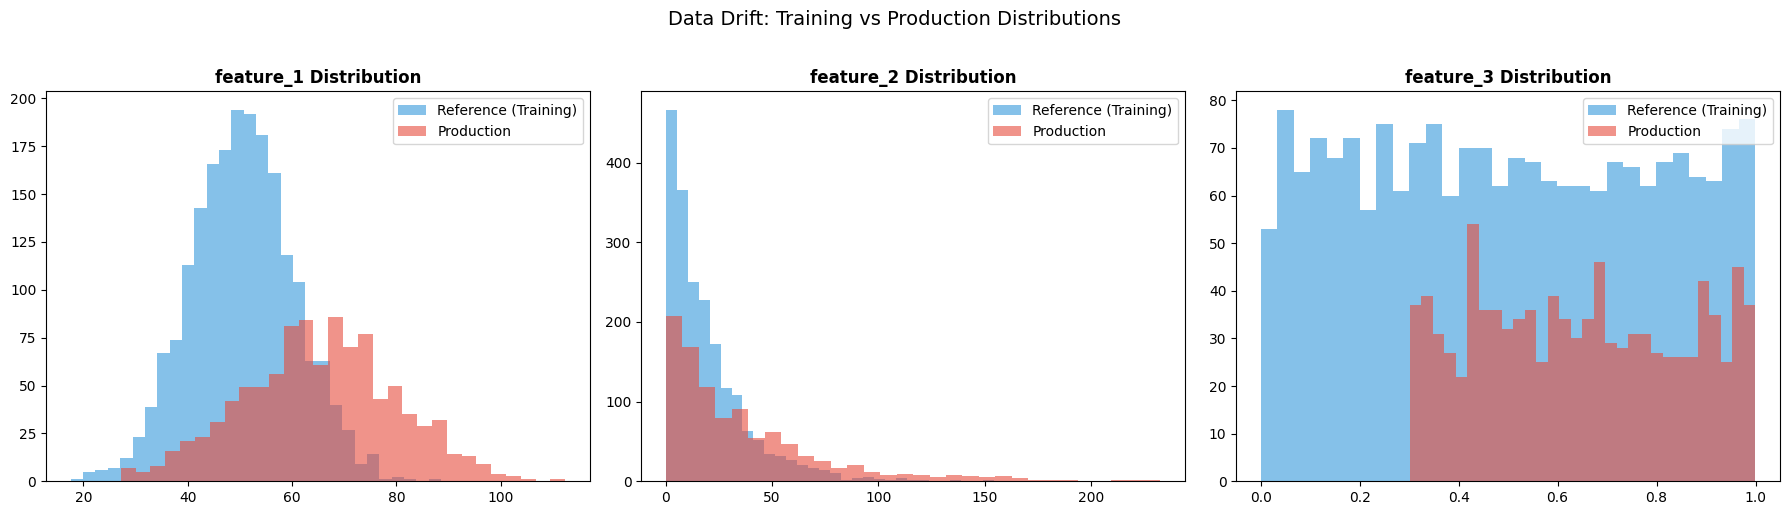

In [4]:
# Visual comparison of distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(['feature_1', 'feature_2', 'feature_3']):
    axes[i].hist(reference_data[col], bins=30, alpha=0.6, label='Reference (Training)', color='#3498db')
    axes[i].hist(production_data[col], bins=30, alpha=0.6, label='Production', color='#e74c3c')
    axes[i].set_title(f'{col} Distribution', fontweight='bold')
    axes[i].legend()
plt.suptitle('Data Drift: Training vs Production Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../data/drift_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# Evidently AI full drift report
ref_num = reference_data.drop('feature_4', axis=1)
prod_num = production_data.drop('feature_4', axis=1)

report = Report(metrics=[DataDriftPreset(), TargetDriftPreset()])
report.run(reference_data=ref_num, current_data=prod_num)
report.save_html('../data/evidently_drift_report.html')
print('Evidently report saved to ../data/evidently_drift_report.html')
print('Open this file in your browser for the full interactive report!')

Evidently report saved to ../data/evidently_drift_report.html
Open this file in your browser for the full interactive report!


## Drift Detection Cheatsheet
| Test | What it detects | Threshold |
|------|----------------|------------|
| KS Test | Continuous feature shift | p < 0.05 |
| Chi-Squared | Categorical feature shift | p < 0.05 |
| PSI | Overall distribution change | > 0.2 = significant |
| Jensen-Shannon | Any distribution | > 0.1 = concern |

**Exercise:** Simulate a gradual drift (week-by-week) and see at which point your model's F1 score degrades significantly!